# CNN on Intel Image Classification

Classes:

`buildings -> 0`, `forest -> 1`, `glacier -> 2`,
`mountain -> 3`, `sea -> 4`, `street -> 5`

## Mount Google Drive

The notebook reads the RAR archive and saves the trained model in Google Drive.

In [68]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Extract and Locate the Dataset

The extraction cell searches recursively for the actual class-bearing folders.
If `seg_train` and `seg_test` are already present, the RAR file is not extracted again.

In [69]:
from pathlib import Path
import os

rar_path = '/content/drive/MyDrive/DATASET/Intel-Image-Classification.rar'
extract_path = '/content/Intel-Image-Classification'
extract_root = Path(extract_path)

required_classes = [
    'buildings', 'forest', 'glacier',
    'mountain', 'sea', 'street'
]


def find_split_path(split_name):
    folders = []
    if extract_root.name == split_name:
        folders.append(extract_root)
    folders.extend(extract_root.rglob(split_name))

    for folder in sorted(
        folders,
        key=lambda path: len(path.parts),
        reverse=True
    ):
        child_folders = {
            child.name for child in folder.iterdir()
            if child.is_dir()
        }
        if set(required_classes).issubset(child_folders):
            return folder
    return None


train_path = find_split_path('seg_train')
test_path = find_split_path('seg_test')

# Install and extract only when the class-bearing folders are missing.
if train_path is None or test_path is None:
    !apt-get update -qq
    !apt-get install -y unrar
    os.makedirs(extract_path, exist_ok=True)
    !unrar x -o+ "{rar_path}" "{extract_path}"
    train_path = find_split_path('seg_train')
    test_path = find_split_path('seg_test')
    print('Dataset extracted successfully')
else:
    print('Dataset is already extracted. Skipping extraction.')

if train_path is None or test_path is None:
    raise FileNotFoundError(
        'Could not find seg_train and seg_test folders containing '
        'buildings, forest, glacier, mountain, sea, and street.'
    )

train_path = str(train_path)
test_path = str(test_path)

# Find seg_pred/images even when the RAR has an extra nested folder.
pred_path = extract_root / 'seg_pred' / 'images'
if not pred_path.exists():
    pred_folders = list(extract_root.rglob('seg_pred'))
    if pred_folders:
        pred_path = pred_folders[0] / 'images'
pred_path = str(pred_path)

print('Training path:', train_path)
print('Testing path:', test_path)
print('Prediction path:', pred_path)

Dataset is already extracted. Skipping extraction.
Training path: /content/Intel-Image-Classification/Intel-Image-Classification/seg_train
Testing path: /content/Intel-Image-Classification/Intel-Image-Classification/seg_test
Prediction path: /content/Intel-Image-Classification/Intel-Image-Classification/seg_pred/images


## Load and Resize Images

`ImageFolder` reads the six class directories and assigns labels alphabetically.
Images are resized to `64 x 64` and `ToTensor()` scales pixel values to `0-1`.

In [70]:
import os
import torch
from torchvision import datasets, transforms

# Folder where the dataset was extracted
extract_path = "/content/Intel-Image-Classification"

# Automatically find dataset folders
train_path = None
test_path = None
pred_path = None

for root, dirs, files in os.walk(extract_path):
    if "seg_train" in dirs:
        train_path = os.path.join(root, "seg_train")
    if "seg_test" in dirs:
        test_path = os.path.join(root, "seg_test")
    if "seg_pred" in dirs:
        pred_path = os.path.join(root, "seg_pred")

# Check that train folder exists
if train_path is None:
    raise FileNotFoundError("seg_train folder not found. Check that the dataset was extracted correctly.")

print("Train Path:", train_path)

# If seg_test is missing, use seg_train as the validation set temporarily
if test_path is None:
    print("Warning: seg_test folder not found.")
    print("Using seg_train as validation data.")
    test_path = train_path

print("Test Path :", test_path)

# Separate transformations for Training and Validation
train_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.RandomHorizontalFlip(),       # Randomly flip the image
    transforms.RandomRotation(15),           # Randomly rotate by up to 15 degrees
    transforms.ColorJitter(brightness=0.1),  # Slightly tweak lighting
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # Normalize colors
])

val_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load datasets using their respective transforms
tr_images = datasets.ImageFolder(root=train_path, transform=train_transform)
val_images = datasets.ImageFolder(root=test_path, transform=val_transform)



# Labels
tr_targets = torch.tensor(tr_images.targets)
val_targets = torch.tensor(val_images.targets)

# Print dataset information
print("\nClass Mapping:")
print(tr_images.class_to_idx)

print("\nTraining Images:", len(tr_images))
print("Validation/Test Images:", len(val_images))

Train Path: /content/Intel-Image-Classification/Intel-Image-Classification/seg_train
Test Path : /content/Intel-Image-Classification/Intel-Image-Classification/seg_test

Class Mapping:
{'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}

Training Images: 14034
Validation/Test Images: 3000


## Imports and Device

CUDA is used automatically when a GPU runtime is available.

In [71]:
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


## Dataset Wrapper

This wrapper keeps the original notebook's simple data-loader pattern and moves each batch to the selected device.

In [72]:
class IntelDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __getitem__(self, ix):
        x, y = self.data[ix]
        return x.to(device), torch.tensor(y).to(device)

    def __len__(self):
        return len(self.data)



## CNN Architecture and Hyperparameters

The CNN model uses the following architecture and hyperparameters:

* **Input size:** `64 × 64` RGB images. Images are resized to this resolution to reduce computational cost while preserving important visual features.
* **Convolutional layers:** Three convolutional layers with **64**, **128**, and **256** filters, respectively. Each layer uses a `3 × 3` kernel with `padding=1` to preserve the spatial dimensions of the feature maps.
* **Batch Normalization:** Applied after each convolutional layer and fully connected layer to stabilize training, accelerate convergence, and improve model performance.
* **Activation function:** `ReLU` is used after every convolutional and fully connected layer to introduce non-linearity.
* **Max Pooling:** A `2 × 2` max pooling layer follows each convolutional block, reducing the spatial dimensions and computational complexity while retaining the most important features.
* **Flatten layer:** Converts the extracted feature maps into a one-dimensional feature vector before passing them to the fully connected layers.
* **Fully Connected layers:** Two dense layers with **512** and **256** neurons are used for high-level feature learning before the final classification layer.
* **Dropout:** A dropout rate of **0.5** is applied after each fully connected layer to reduce overfitting by randomly deactivating neurons during training.
* **Output layer:** A final fully connected layer with **6 neurons**, corresponding to the six image classes in the Intel Image Classification dataset.
* **Batch size:** `64`, providing a balance between GPU memory usage and training efficiency.
* **Optimizer:** **Adam** optimizer with a learning rate of **0.001** and **weight decay of 0.0001** for adaptive optimization and L2 regularization.
* **Loss function:** **CrossEntropyLoss**, suitable for multi-class image classification problems with six mutually exclusive classes.
* **Epochs:** `20`, allowing the model sufficient training iterations to learn discriminative features while monitoring training and validation performance.


In [73]:
from torch.optim import Adam


def get_model():
    model = nn.Sequential(
        # --- BLOCK 1 ---
        nn.Conv2d(3, 64, kernel_size=3, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.Conv2d(64, 64, kernel_size=3, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(2),
        # Reduced dropout so the model isn't starved of features early on
        nn.Dropout2d(0.1),

        # --- BLOCK 2 ---
        nn.Conv2d(64, 128, kernel_size=3, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.Conv2d(128, 128, kernel_size=3, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Dropout2d(0.2),

        # --- BLOCK 3 ---
        nn.Conv2d(128, 256, kernel_size=3, padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU(),
        nn.Conv2d(256, 256, kernel_size=3, padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Dropout2d(0.3),

        # --- CLASSIFICATION HEAD ---
        nn.AdaptiveAvgPool2d(1),
        nn.Flatten(),

        # Added a small buffer layer to stabilize the transition to classes
        nn.Linear(256, 128),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(128, 6)
    ).to(device)

    loss_fn = nn.CrossEntropyLoss()

    # CRITICAL CHANGE: Lowered Learning Rate to 1e-4 and reduced weight decay
    optimizer = Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

    return model, loss_fn, optimizer

## Training and Accuracy Helpers

These functions preserve the original training workflow: one function updates the CNN for a batch,
while the accuracy helper checks the predicted class for each image.

In [74]:
def train_batch(x, y, model, opt, loss_fn):
    model.train()
    prediction = model(x)
    batch_loss = loss_fn(prediction, y)
    batch_loss.backward()
    opt.step()
    opt.zero_grad()
    return batch_loss.item()


@torch.no_grad()
def accuracy(x, y, model):
    model.eval()
    prediction = model(x)
    max_values, argmaxes = prediction.max(-1)
    is_correct = argmaxes == y
    return is_correct.cpu().numpy().tolist()

## Data Loaders and Validation Loss

Training and test images are loaded in batches of `64`. The test loader does not shuffle images,
which makes evaluation reproducible.

In [75]:
def get_data():
    train = IntelDataset(tr_images)
    trn_dl = DataLoader(train, batch_size=64, shuffle=True)

    val = IntelDataset(val_images)
    val_dl = DataLoader(val, batch_size=64, shuffle=False)
    return trn_dl, val_dl


@torch.no_grad()
def val_loss(x, y, model):
    model.eval()
    prediction = model(x)
    validation_loss = loss_fn(prediction, y)
    return validation_loss.item()

## Create the Model

The summary confirms the unchanged CNN structure and six output logits, one for each scene class.

In [88]:
trn_dl, val_dl = get_data()
model, loss_fn, optimizer = get_model()

!pip -q install torchsummary
from torchsummary import summary
summary(model, (3, 64, 64))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 64, 64]           1,792
       BatchNorm2d-2           [-1, 64, 64, 64]             128
              ReLU-3           [-1, 64, 64, 64]               0
         MaxPool2d-4           [-1, 64, 32, 32]               0
            Conv2d-5          [-1, 128, 32, 32]          73,856
       BatchNorm2d-6          [-1, 128, 32, 32]             256
              ReLU-7          [-1, 128, 32, 32]               0
         MaxPool2d-8          [-1, 128, 16, 16]               0
            Conv2d-9          [-1, 256, 16, 16]         295,168
      BatchNorm2d-10          [-1, 256, 16, 16]             512
             ReLU-11          [-1, 256, 16, 16]               0
        MaxPool2d-12            [-1, 256, 8, 8]               0
          Flatten-13                [-1, 16384]               0
           Linear-14                  [

## Train the CNN

The original five-epoch training loop remains unchanged.

In [89]:
train_losses, train_accuracies = [], []
val_losses, val_accuracies = [], []

for epoch in range(35):
    print(epoch)
    train_epoch_losses, train_epoch_accuracies = [], []

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        train_epoch_losses.append(batch_loss)

    train_epoch_loss = np.array(train_epoch_losses).mean()

    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        is_correct = accuracy(x, y, model)
        train_epoch_accuracies.extend(is_correct)

    train_epoch_accuracy = np.mean(train_epoch_accuracies)

    val_epoch_losses, val_epoch_accuracies = [], []
    for ix, batch in enumerate(iter(val_dl)):
        x, y = batch
        val_epoch_accuracies.extend(accuracy(x, y, model))
        val_epoch_losses.append(val_loss(x, y, model))

    validation_loss = np.mean(val_epoch_losses)
    val_epoch_accuracy = np.mean(val_epoch_accuracies)

    train_losses.append(train_epoch_loss)
    train_accuracies.append(train_epoch_accuracy)
    val_losses.append(validation_loss)
    val_accuracies.append(val_epoch_accuracy)

    #print epoch wise details
    print(f"Epoch {epoch+1}/20 | "
      f"Train Loss: {train_epoch_loss:.4f} | "
      f"Train Acc: {train_epoch_accuracy*100:.2f}% | "
      f"Val Loss: {validation_loss:.4f} | "
      f"Val Acc: {val_epoch_accuracy*100:.2f}%")

0
Epoch 1/20 | Train Loss: 0.9076 | Train Acc: 74.50% | Val Loss: 0.6771 | Val Acc: 75.73%
1
Epoch 2/20 | Train Loss: 0.6884 | Train Acc: 76.00% | Val Loss: 0.5954 | Val Acc: 78.67%
2
Epoch 3/20 | Train Loss: 0.6227 | Train Acc: 80.22% | Val Loss: 0.5156 | Val Acc: 81.23%
3
Epoch 4/20 | Train Loss: 0.5660 | Train Acc: 76.76% | Val Loss: 0.6488 | Val Acc: 77.50%
4
Epoch 5/20 | Train Loss: 0.5385 | Train Acc: 80.07% | Val Loss: 0.5239 | Val Acc: 80.67%
5
Epoch 6/20 | Train Loss: 0.5111 | Train Acc: 84.42% | Val Loss: 0.4649 | Val Acc: 83.83%
6
Epoch 7/20 | Train Loss: 0.4946 | Train Acc: 82.99% | Val Loss: 0.4740 | Val Acc: 83.03%
7
Epoch 8/20 | Train Loss: 0.4777 | Train Acc: 82.18% | Val Loss: 0.5310 | Val Acc: 81.70%
8
Epoch 9/20 | Train Loss: 0.4748 | Train Acc: 80.56% | Val Loss: 0.5557 | Val Acc: 80.50%
9
Epoch 10/20 | Train Loss: 0.4500 | Train Acc: 84.72% | Val Loss: 0.4236 | Val Acc: 85.20%
10
Epoch 11/20 | Train Loss: 0.4351 | Train Acc: 84.30% | Val Loss: 0.4536 | Val Acc: 84.

## Training Curves

These plots show whether training and test loss decrease and whether accuracy improves over the five epochs.

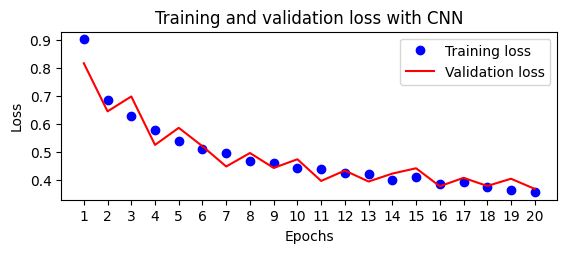

/tmp/ipykernel_2296/2756971494.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels([


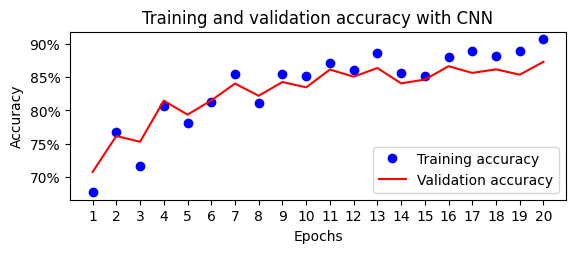

In [78]:
epochs = np.arange(35) + 1
import matplotlib.ticker as mticker

plt.subplot(211)
plt.plot(epochs, train_losses, 'bo', label='Training loss')
plt.plot(epochs, val_losses, 'r', label='Validation loss')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation loss with CNN')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(False)
plt.show()

plt.subplot(212)
plt.plot(epochs, train_accuracies, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracies, 'r', label='Validation accuracy')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Training and validation accuracy with CNN')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.gca().set_yticklabels([
    '{:.0f}%'.format(x * 100) for x in plt.gca().get_yticks()
])
plt.legend()
plt.grid(False)
plt.show()

## Model Evaluation on the Test Set

The `seg_test` folder is used as the test set. This section reports:

- Test loss and accuracy
- Macro and weighted precision, recall, and F1-score
- A complete per-class classification report

The existing CNN and training loop above are unchanged.

In [79]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)
import pandas as pd

classes = tr_images.classes
model.eval()
test_loss_total = 0.0
test_sample_count = 0
test_targets = []
test_predictions = []

with torch.no_grad():
    for x, y in val_dl:
        prediction = model(x)
        batch_loss = loss_fn(prediction, y)
        predicted_classes = prediction.argmax(dim=1)

        # Weight each batch loss by its number of test images.
        test_loss_total += batch_loss.item() * y.size(0)
        test_sample_count += y.size(0)
        test_targets.extend(y.cpu().numpy())
        test_predictions.extend(predicted_classes.cpu().numpy())

test_loss = test_loss_total / test_sample_count
test_accuracy = accuracy_score(test_targets, test_predictions)
macro_precision = precision_score(
    test_targets, test_predictions, average='macro', zero_division=0
)
macro_recall = recall_score(
    test_targets, test_predictions, average='macro', zero_division=0
)
macro_f1 = f1_score(
    test_targets, test_predictions, average='macro', zero_division=0
)
weighted_precision = precision_score(
    test_targets, test_predictions, average='weighted', zero_division=0
)
weighted_recall = recall_score(
    test_targets, test_predictions, average='weighted', zero_division=0
)
weighted_f1 = f1_score(
    test_targets, test_predictions, average='weighted', zero_division=0
)

metrics = pd.DataFrame({
    'Metric': [
        'Test loss',
        'Accuracy',
        'Macro precision',
        'Macro recall',
        'Macro F1-score',
        'Weighted precision',
        'Weighted recall',
        'Weighted F1-score',
    ],
    'Value': [
        test_loss,
        test_accuracy,
        macro_precision,
        macro_recall,
        macro_f1,
        weighted_precision,
        weighted_recall,
        weighted_f1,
    ],
})

print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy: {test_accuracy:.4f}')
display(metrics.style.format({'Value': '{:.4f}'}))

report = classification_report(
    test_targets,
    test_predictions,
    labels=list(range(len(classes))),
    target_names=classes,
    output_dict=True,
    zero_division=0,
)
classification_report_df = pd.DataFrame(report).transpose()
display(classification_report_df.style.format({
    'precision': '{:.4f}',
    'recall': '{:.4f}',
    'f1-score': '{:.4f}',
    'support': '{:.0f}',
}))

Test loss: 0.3668
Test accuracy: 0.8730


,Metric,Value
0,Test loss,0.3668
1,Accuracy,0.8730
2,Macro precision,0.8751
3,Macro recall,0.8750
4,Macro F1-score,0.8746
5,Weighted precision,0.8735
6,Weighted recall,0.8730
7,Weighted F1-score,0.8728


,precision,recall,f1-score,support
buildings,0.8674,0.8535,0.8604,437
forest,0.9705,0.9705,0.9705,474
glacier,0.8538,0.8029,0.8276,553
mountain,0.8229,0.8229,0.8229,525
sea,0.8327,0.9078,0.8687,510
street,0.9030,0.8922,0.8976,501
accuracy,0.8730,0.8730,0.8730,1
macro avg,0.8751,0.8750,0.8746,3000
weighted avg,0.8735,0.8730,0.8728,3000


## Confusion Matrix

Rows show the true class and columns show the predicted class. The normalized matrix
makes it easier to compare classes even when their image counts differ.

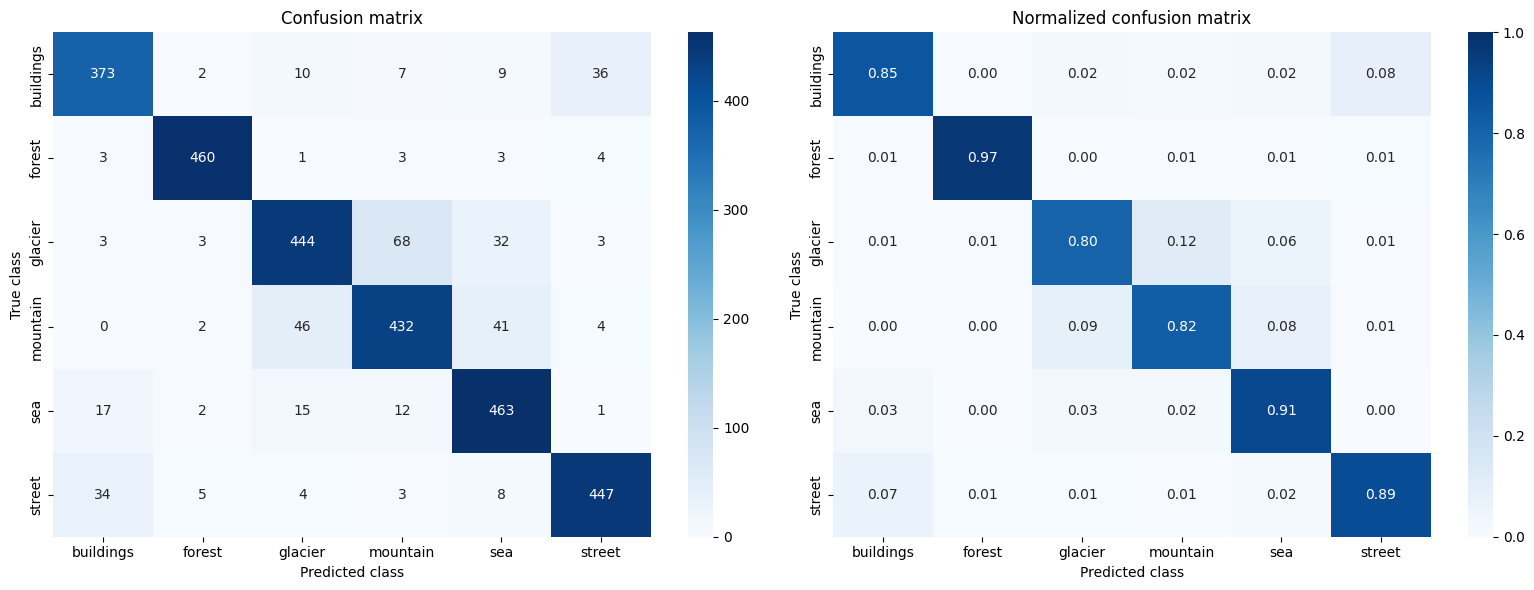

In [80]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

confusion = confusion_matrix(
    test_targets,
    test_predictions,
    labels=list(range(len(classes))),
)
confusion_normalized = confusion.astype(float) / confusion.sum(
    axis=1, keepdims=True
)

figure, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    confusion,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes,
    ax=axes[0],
)
axes[0].set_title('Confusion matrix')
axes[0].set_xlabel('Predicted class')
axes[0].set_ylabel('True class')

sns.heatmap(
    confusion_normalized,
    annot=True,
    fmt='.2f',
    cmap='Blues',
    vmin=0,
    vmax=1,
    xticklabels=classes,
    yticklabels=classes,
    ax=axes[1],
)
axes[1].set_title('Normalized confusion matrix')
axes[1].set_xlabel('Predicted class')
axes[1].set_ylabel('True class')

plt.tight_layout()
plt.show()

## Per-Class Performance Analysis

F1-score balances precision and recall, so it is used to identify the best and worst
performing scene classes. The chart also shows each class's precision, recall, and F1-score.

Best performing class: forest (F1-score: 0.9705)
Worst performing class: mountain (F1-score: 0.8229)


,precision,recall,f1-score,support
forest,0.9705,0.9705,0.9705,474
street,0.9030,0.8922,0.8976,501
sea,0.8327,0.9078,0.8687,510
buildings,0.8674,0.8535,0.8604,437
glacier,0.8538,0.8029,0.8276,553
mountain,0.8229,0.8229,0.8229,525


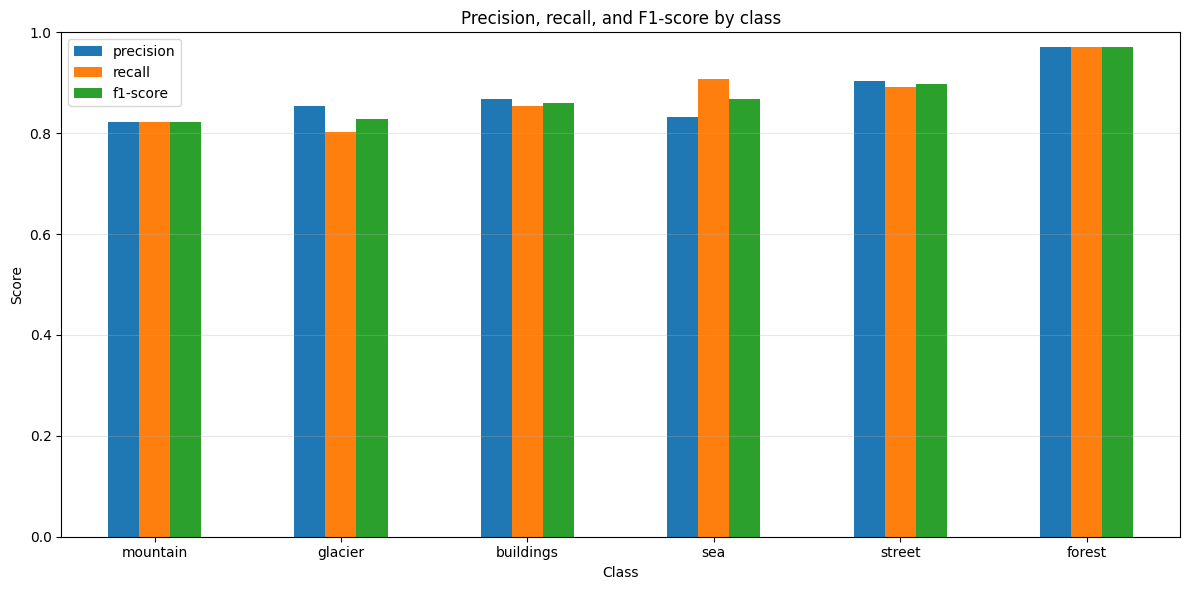

In [81]:
per_class_results = classification_report_df.loc[
    classes,
    ['precision', 'recall', 'f1-score', 'support'],
].copy()
per_class_results = per_class_results.sort_values(
    'f1-score',
    ascending=False,
)

best_class = per_class_results.index[0]
worst_class = per_class_results.index[-1]

print(
    f'Best performing class: {best_class} '
    f'(F1-score: {per_class_results.loc[best_class, "f1-score"]:.4f})'
)
print(
    f'Worst performing class: {worst_class} '
    f'(F1-score: {per_class_results.loc[worst_class, "f1-score"]:.4f})'
)
display(per_class_results.style.format({
    'precision': '{:.4f}',
    'recall': '{:.4f}',
    'f1-score': '{:.4f}',
    'support': '{:.0f}',
}))

per_class_results[['precision', 'recall', 'f1-score']].sort_values(
    'f1-score'
).plot(
    kind='bar',
    figsize=(12, 6),
    ylim=(0, 1),
    title='Precision, recall, and F1-score by class',
)
plt.xlabel('Class')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Save Trained Model Weights

Only the learned `state_dict` is saved, which is the standard PyTorch format for model weights.
The file is stored in the same Drive `DATASET` folder.

In [82]:
model_weights_path = (
    '/content/drive/MyDrive/DATASET/intel_image_cnn_weights.pth'
)
torch.save(model.state_dict(), model_weights_path)
print('Saved model weights to:', model_weights_path)

Saved model weights to: /content/drive/MyDrive/DATASET/intel_image_cnn_weights.pth


## Translation Robustness Check

This keeps the original translation experiment and checks how horizontal shifts affect class probabilities.

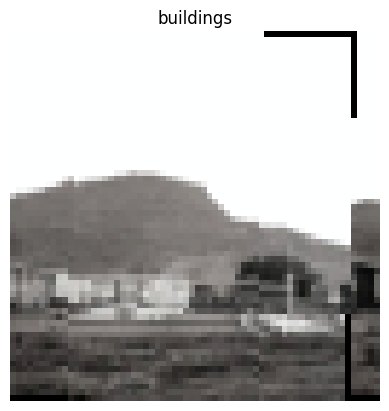

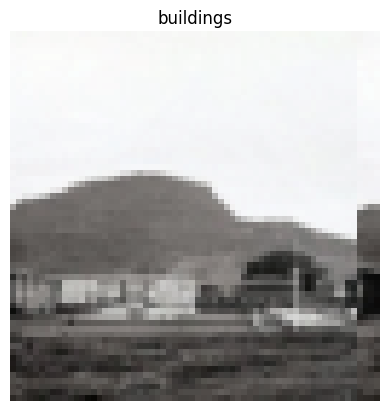

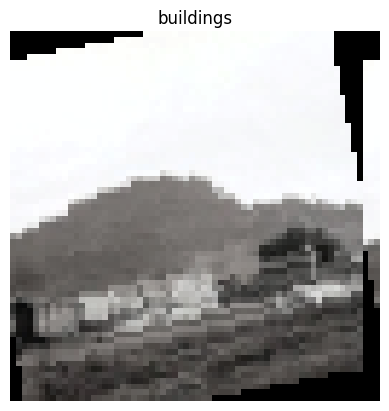

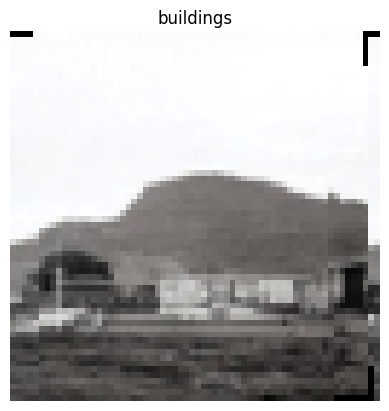

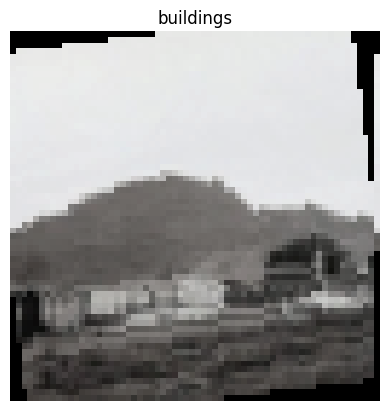

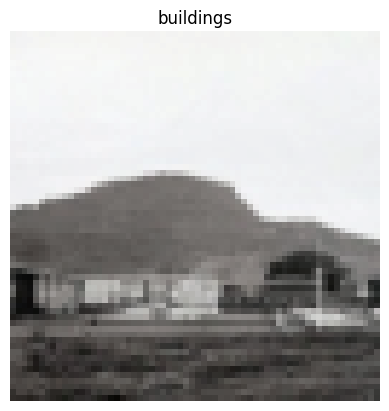

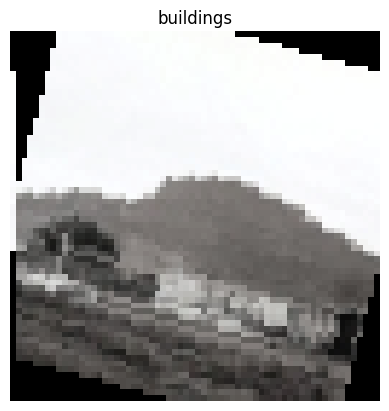

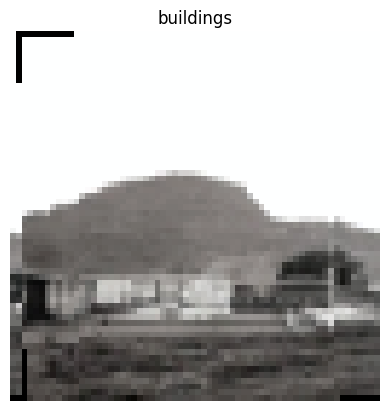

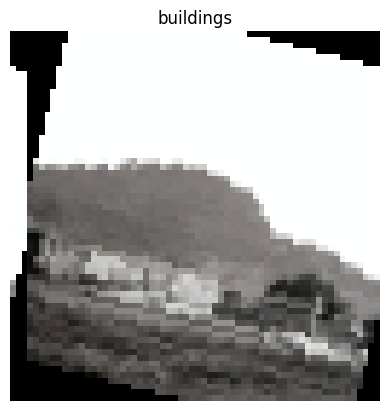

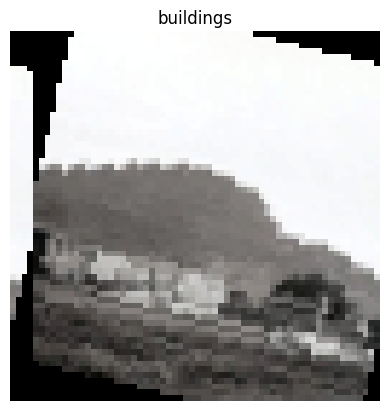

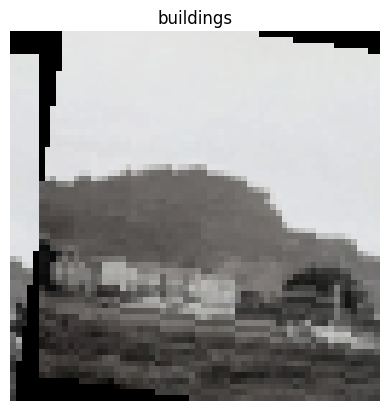

(11, 1, 6)

In [107]:
import numpy as np

classes = ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

preds = []
ix = 0

for px in range(-5, 6):
    img, actual_class = tr_images[ix]
    img2 = torch.roll(img, shifts=px, dims=2)
    img3 = img2.view(-1, 3, 64, 64).to(device)

    output = model(img3)
    pred = torch.softmax(output, dim=1).cpu().detach().numpy()
    preds.append(pred)

    # 1. Convert the PyTorch tensor to a Numpy array for Matplotlib
    img_display = img2.permute(1, 2, 0).cpu().numpy()

    # 2. Reverse the Normalization math using the exact values from train_transform
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_display = std * img_display + mean

    # 3. Clip any floating point errors to strictly 0.0 to 1.0
    img_display = np.clip(img_display, 0, 1)

    # 4. Plot the cleaned up image
    plt.imshow(img_display)
    # -----------------------------------

    plt.title(classes[pred[0].argmax()])
    plt.axis('off')
    plt.show()

np.array(preds).shape

<Axes: title={'center': 'Probability of each class for various translations'}>

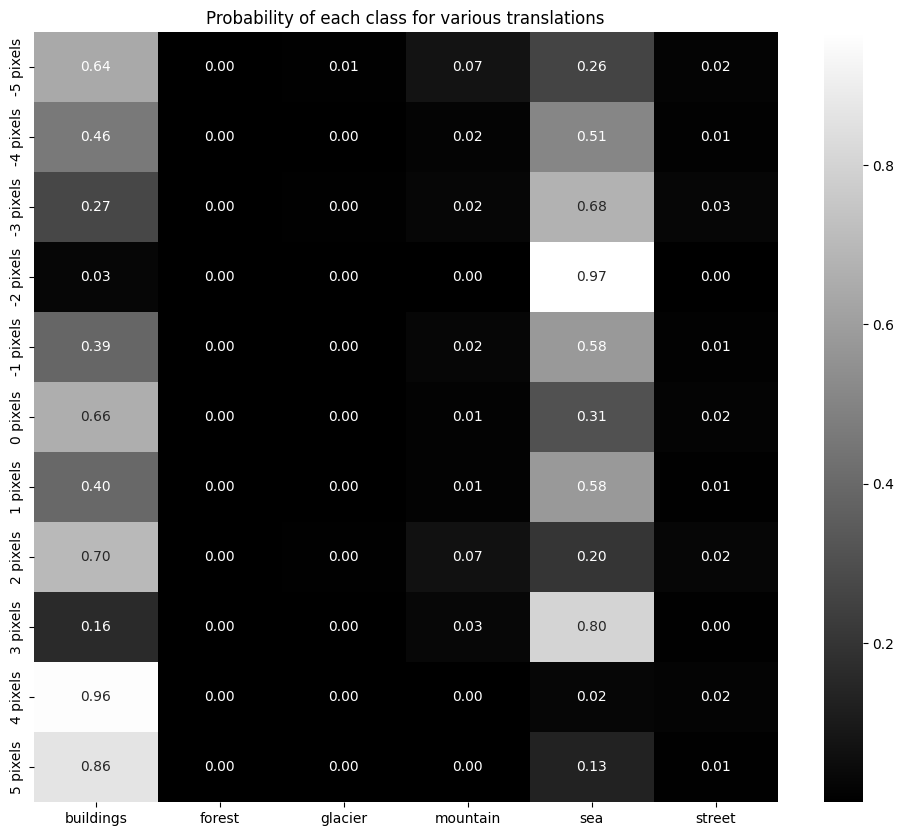

In [84]:
import seaborn as sns

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
plt.title('Probability of each class for various translations')

sns.heatmap(
    np.array(preds).reshape(11, 6),
    annot=True,
    ax=ax,
    fmt='.2f',
    xticklabels=classes,
    yticklabels=[str(i) + ' pixels' for i in range(-5, 6)],
    cmap='gray'
)

## Predict images from `seg_pred/images`

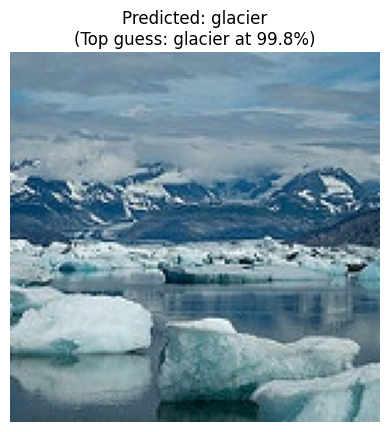

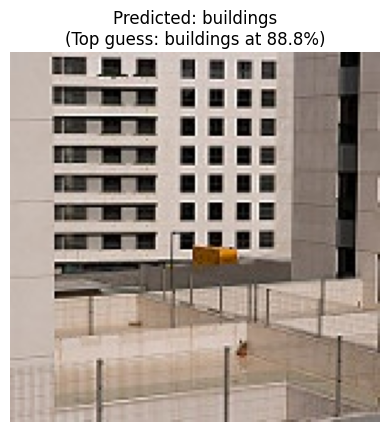

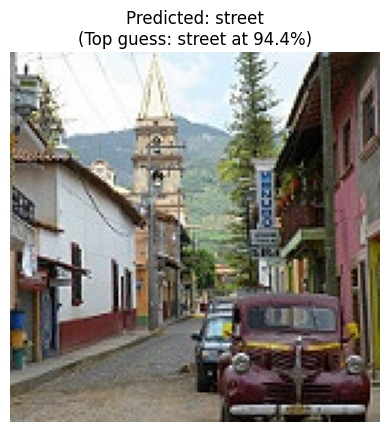

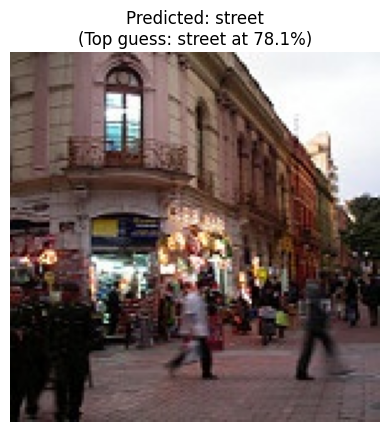

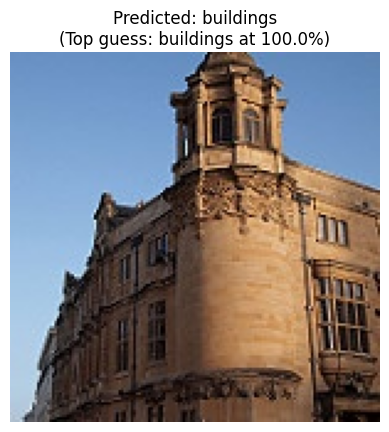

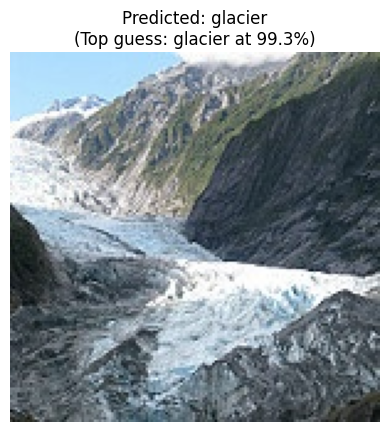

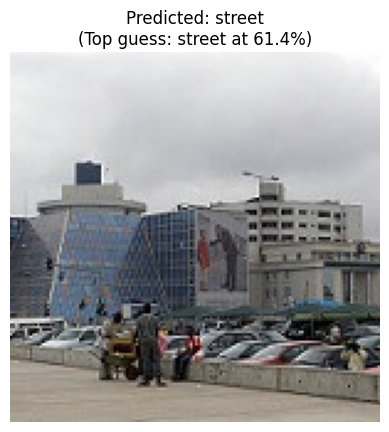

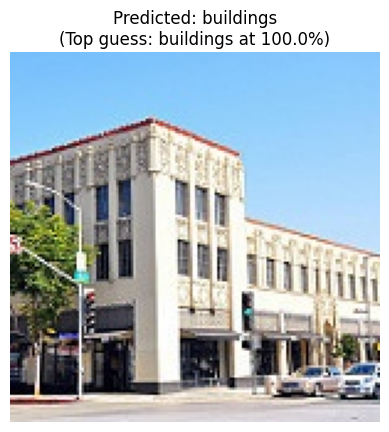

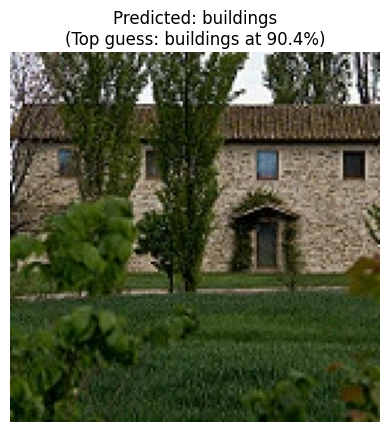

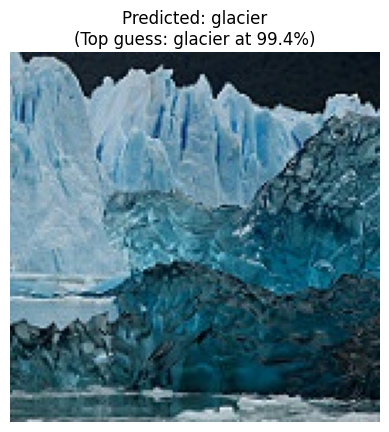

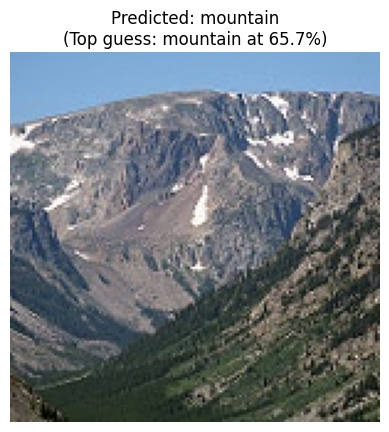

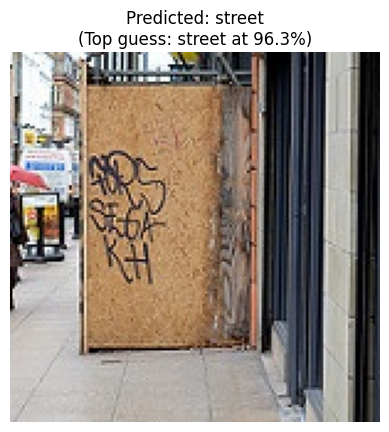

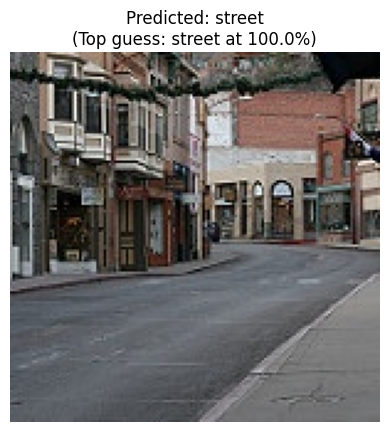

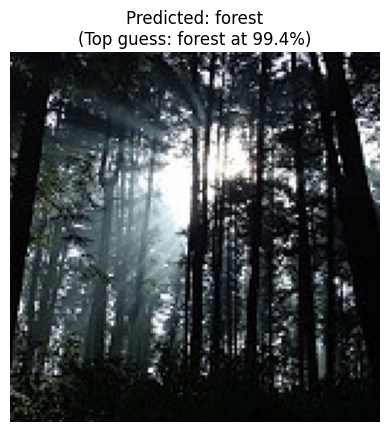

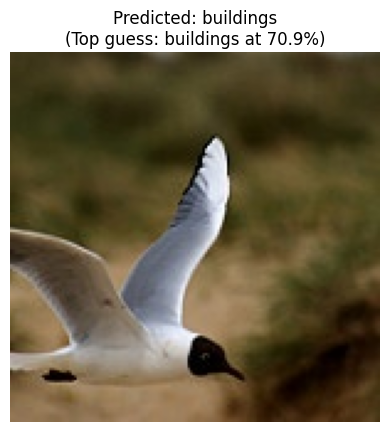

In [105]:
import torch.nn.functional as F

with torch.no_grad():
    for image_path in prediction_images[:15]:
        image = Image.open(image_path).convert('RGB')
        image_tensor = predict_transform(image).unsqueeze(0).to(device)

        output = model(image_tensor)

        # Convert raw output numbers into percentages (0.0 to 1.0)
        probabilities = F.softmax(output, dim=1)[0] * 100

        predicted_class_idx = output.argmax(dim=1).item()
        predicted_class_name = classes[predicted_class_idx]
        confidence = probabilities[predicted_class_idx].item()

        #  Confidence Threshold ---
        if confidence < 55.0:
            final_prediction = "Unknown (Image not in dataset)"
        else:
            final_prediction = predicted_class_name

        plt.imshow(image)
        plt.title(f"Predicted: {final_prediction}\n(Top guess: {predicted_class_name} at {confidence:.1f}%)")
        plt.axis('off')
        plt.show()



